# Demonstracao de avaliacao e predicao

Este notebook carrega o melhor modelo salvo em `models/best_model.pt`, carrega as classes em `models/class_names.json`, aplica o mesmo pre-processamento deterministico usado no teste e executa predicoes em imagens novas ou em amostras do conjunto de teste.

Nao ha retreinamento neste notebook. A demonstracao usa somente o checkpoint, os metadados salvos e imagens do repositorio.

## Contexto do problema

O projeto resolve uma tarefa de classificacao de uso e cobertura do solo em imagens RGB de sensoriamento remoto do dataset `EuroSAT_RGB`. A aplicacao e compativel com fluxos de observacao da Terra, nos quais recortes de imagens podem ser classificados automaticamente para apoiar monitoramento ambiental, planejamento territorial e analise de infraestrutura.

Classes esperadas: `AnnualCrop`, `Forest`, `HerbaceousVegetation`, `Highway`, `Industrial`, `Pasture`, `PermanentCrop`, `Residential`, `River` e `SeaLake`.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import torch
from IPython.display import display

current_dir = Path.cwd()
if (current_dir / "models" / "best_model.pt").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "models" / "best_model.pt").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Nao encontrei models/best_model.pt. Execute o notebook a partir da raiz "
        "do repositorio ou da pasta notebooks/."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.baseline_cnn import BaselineCNN
from src.models.improved_cnn import ImprovedCNN
from src.transforms import build_inference_transforms

BEST_MODEL_PATH = PROJECT_ROOT / "models" / "best_model.pt"
CLASS_NAMES_PATH = PROJECT_ROOT / "models" / "class_names.json"
METRICS_PATH = PROJECT_ROOT / "models" / "metrics.json"
TEST_CSV_PATH = PROJECT_ROOT / "data" / "processed" / "test.csv"
PROJECT_ROOT_DISPLAY = "." if PROJECT_ROOT == current_dir else ".."

MODEL_CLASSES = {
    "baseline": BaselineCNN,
    "improved": ImprovedCNN,
}

print(f"Raiz do projeto: {PROJECT_ROOT_DISPLAY}")
print(f"Checkpoint: {BEST_MODEL_PATH.relative_to(PROJECT_ROOT)}")

Raiz do projeto: ..
Checkpoint: models\best_model.pt


## Carregamento do modelo e dos metadados

A celula abaixo carrega o checkpoint, as classes e as metricas ja documentadas. O tipo de CNN e inferido do proprio checkpoint salvo, entao a demonstracao permanece alinhada ao melhor modelo escolhido no treinamento.

In [2]:
def load_json(path: Path):
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_checkpoint(path: Path, device: torch.device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def choose_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def extract_class_names(payload) -> list[str]:
    if isinstance(payload, dict) and "class_names" in payload:
        return list(payload["class_names"])
    if isinstance(payload, list):
        return list(payload)
    raise ValueError("Formato invalido em models/class_names.json")


device = choose_device()
class_payload = load_json(CLASS_NAMES_PATH)
metrics = load_json(METRICS_PATH)
checkpoint = load_checkpoint(BEST_MODEL_PATH, device)
class_names = extract_class_names(class_payload)

checkpoint_classes = checkpoint.get("class_names")
if checkpoint_classes and list(checkpoint_classes) != class_names:
    raise ValueError("As classes do checkpoint diferem de models/class_names.json")

model_key = checkpoint.get("model_key") or metrics.get("best_model", {}).get("model_key")
if model_key not in MODEL_CLASSES:
    raise ValueError(f"Modelo desconhecido no checkpoint: {model_key!r}")

input_size = tuple(checkpoint.get("input_size", metrics.get("input_size", [64, 64])))
normalization = checkpoint.get("normalization") or metrics.get("normalization")
if not normalization:
    raise ValueError("Nao encontrei estatisticas de normalizacao no checkpoint ou nas metricas.")
mean = normalization["mean"]
std = normalization["std"]

best_metrics = metrics["models"][model_key]
print(f"Device selecionado: {device}")
print(f"Modelo salvo: {checkpoint.get('model_name', model_key)}")
print(f"Classes: {len(class_names)}")
print(f"Input size: {input_size}")
print(f"Normalizacao mean={mean}, std={std}")
print(f"Accuracy de teste documentada: {best_metrics['test']['accuracy']:.4f}")
print(f"Loss de teste documentada: {best_metrics['test']['loss']:.4f}")

Device selecionado: cpu
Modelo salvo: ImprovedCNN
Classes: 10
Input size: (64, 64)
Normalizacao mean=[0.3438271126, 0.3799947054, 0.407612037], std=[0.2024812323, 0.1369397151, 0.1156126249]
Accuracy de teste documentada: 0.9153
Loss de teste documentada: 0.2400


In [3]:
ModelClass = MODEL_CLASSES[model_key]
model = ModelClass(num_classes=len(class_names))
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

preprocess = build_inference_transforms(mean=mean, std=std, input_size=input_size)

print("Modelo carregado sem retreinamento.")
print("Pre-processamento de inferencia configurado com Resize, ToTensor e Normalize.")

Modelo carregado sem retreinamento.
Pre-processamento de inferencia configurado com Resize, ToTensor e Normalize.


## Predicao em uma imagem

Por padrao, a demonstracao usa uma amostra do conjunto de teste. Para testar uma imagem nova, altere `DEMO_IMAGE_PATH` para o caminho relativo ou absoluto de outro arquivo `.jpg`, `.jpeg` ou `.png`.

In [4]:
def resolve_image_path(path_value: str | Path) -> Path:
    path = Path(path_value)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path


@torch.inference_mode()
def predict_image(image_path: str | Path, top_k: int = 3) -> dict:
    resolved_path = resolve_image_path(image_path)
    if not resolved_path.exists():
        raise FileNotFoundError(f"Imagem nao encontrada: {resolved_path}")

    image = Image.open(resolved_path).convert("RGB")
    tensor = preprocess(image).unsqueeze(0).to(device)
    logits = model(tensor)
    probabilities = torch.softmax(logits, dim=1).squeeze(0).detach().cpu()

    k = min(top_k, len(class_names))
    top_probabilities, top_indices = torch.topk(probabilities, k=k)
    rows = []
    for probability, index in zip(top_probabilities.tolist(), top_indices.tolist(), strict=True):
        rows.append(
            {
                "classe": class_names[int(index)],
                "probabilidade": float(probability),
            }
        )

    prediction_table = pd.DataFrame(rows)
    return {
        "path": resolved_path,
        "image": image,
        "predicted_class": rows[0]["classe"],
        "confidence": rows[0]["probabilidade"],
        "top_k": prediction_table,
    }


def show_single_prediction(result: dict) -> None:
    plt.figure(figsize=(4, 4))
    plt.imshow(result["image"])
    plt.axis("off")
    plt.title(
        f"Predicao: {result['predicted_class']} ({result['confidence']:.1%})",
        fontsize=11,
    )
    plt.show()
    display(result["top_k"].style.format({"probabilidade": "{:.2%}"}))

Imagem avaliada: EuroSAT_RGB\AnnualCrop\AnnualCrop_100.jpg


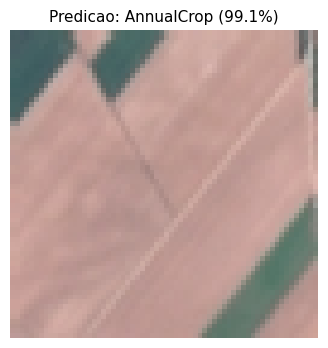

,classe,probabilidade
0,AnnualCrop,99.10%
1,PermanentCrop,0.46%
2,HerbaceousVegetation,0.36%


In [5]:
demo_examples = best_metrics["prediction_examples"]["correct"]
if not demo_examples:
    raise ValueError("Nao ha exemplos corretos registrados em models/metrics.json")

DEMO_IMAGE_PATH = Path(demo_examples[0]["relative_path"])

single_result = predict_image(DEMO_IMAGE_PATH, top_k=3)
print(f"Imagem avaliada: {single_result['path'].relative_to(PROJECT_ROOT)}")
show_single_prediction(single_result)

## Exemplos de acertos e erros

As proximas celulas reaplicam a inferencia do checkpoint em exemplos registrados durante a avaliacao do melhor modelo. A tabela e as imagens mostram a classe real, a classe prevista e a confianca da predicao.

In [6]:
def evaluate_saved_examples(kind: str, limit: int = 6) -> list[dict]:
    examples = best_metrics["prediction_examples"].get(kind, [])[:limit]
    evaluated = []
    for example in examples:
        prediction = predict_image(example["relative_path"], top_k=3)
        evaluated.append(
            {
                "path": prediction["path"],
                "relative_path": example["relative_path"],
                "true_class": example["true_class"],
                "predicted_class": prediction["predicted_class"],
                "confidence": prediction["confidence"],
                "matches_label": example["true_class"] == prediction["predicted_class"],
            }
        )
    return evaluated


def plot_prediction_examples(examples: list[dict], title: str) -> pd.DataFrame:
    if not examples:
        print(f"Sem exemplos para: {title}")
        return pd.DataFrame()

    columns = 3
    rows = (len(examples) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(columns * 3.2, rows * 3.5))
    axes = np.atleast_1d(axes).ravel().tolist()

    for axis in axes:
        axis.axis("off")

    for axis, example in zip(axes, examples, strict=False):
        image = Image.open(example["path"]).convert("RGB")
        color = "darkgreen" if example["matches_label"] else "crimson"
        axis.imshow(image)
        axis.set_title(
            f"Real: {example['true_class']}\nPred: {example['predicted_class']} ({example['confidence']:.1%})",
            color=color,
            fontsize=9,
        )
        axis.axis("off")

    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()

    table = pd.DataFrame(
        [
            {
                "imagem": item["relative_path"],
                "classe_real": item["true_class"],
                "classe_predita": item["predicted_class"],
                "confianca": item["confidence"],
                "acerto": item["matches_label"],
            }
            for item in examples
        ]
    )
    return table

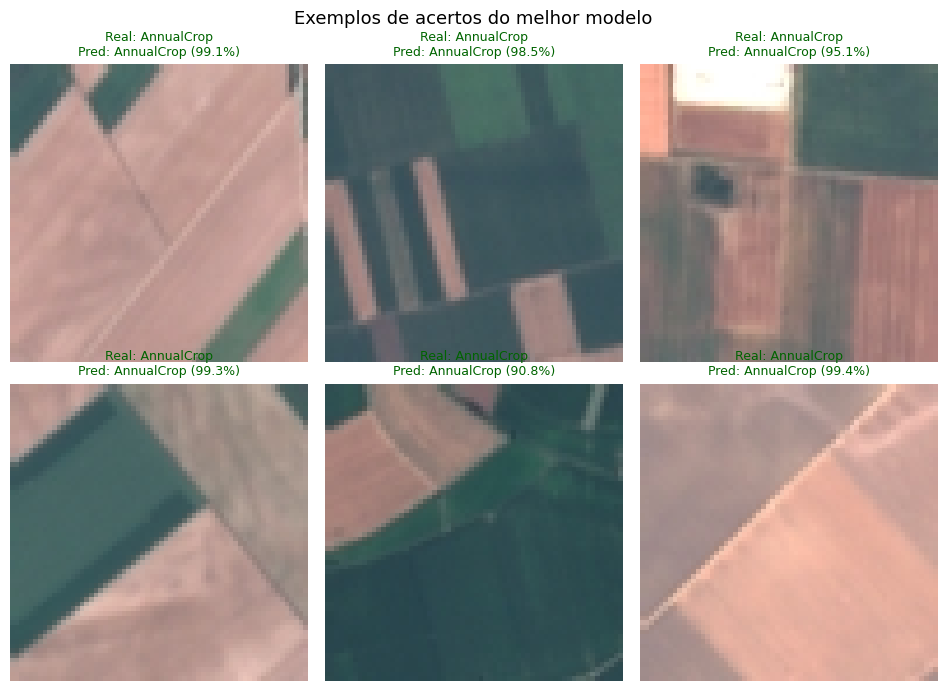

,imagem,classe_real,classe_predita,confianca,acerto
0,EuroSAT_RGB/AnnualCrop/AnnualCrop_100.jpg,AnnualCrop,AnnualCrop,99.10%,True
1,EuroSAT_RGB/AnnualCrop/AnnualCrop_1005.jpg,AnnualCrop,AnnualCrop,98.53%,True
2,EuroSAT_RGB/AnnualCrop/AnnualCrop_1010.jpg,AnnualCrop,AnnualCrop,95.05%,True
3,EuroSAT_RGB/AnnualCrop/AnnualCrop_1021.jpg,AnnualCrop,AnnualCrop,99.32%,True
4,EuroSAT_RGB/AnnualCrop/AnnualCrop_1024.jpg,AnnualCrop,AnnualCrop,90.78%,True
5,EuroSAT_RGB/AnnualCrop/AnnualCrop_1027.jpg,AnnualCrop,AnnualCrop,99.35%,True


In [7]:
correct_examples = evaluate_saved_examples("correct", limit=6)
correct_table = plot_prediction_examples(correct_examples, "Exemplos de acertos do melhor modelo")
display(correct_table.style.format({"confianca": "{:.2%}"}))

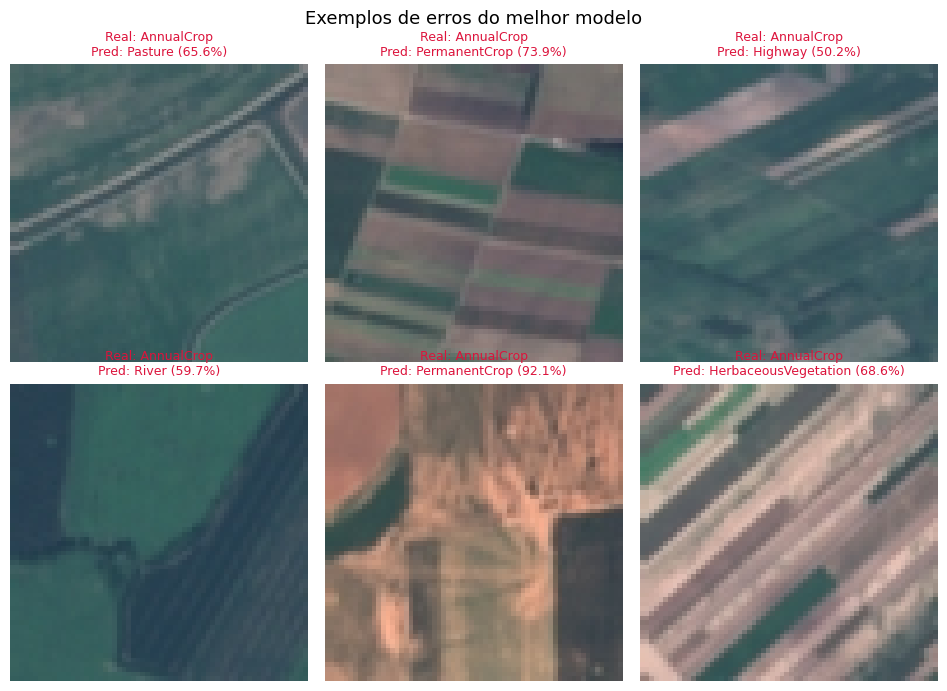

,imagem,classe_real,classe_predita,confianca,acerto
0,EuroSAT_RGB/AnnualCrop/AnnualCrop_101.jpg,AnnualCrop,Pasture,65.58%,False
1,EuroSAT_RGB/AnnualCrop/AnnualCrop_1234.jpg,AnnualCrop,PermanentCrop,73.86%,False
2,EuroSAT_RGB/AnnualCrop/AnnualCrop_1266.jpg,AnnualCrop,Highway,50.15%,False
3,EuroSAT_RGB/AnnualCrop/AnnualCrop_1294.jpg,AnnualCrop,River,59.68%,False
4,EuroSAT_RGB/AnnualCrop/AnnualCrop_1355.jpg,AnnualCrop,PermanentCrop,92.09%,False
5,EuroSAT_RGB/AnnualCrop/AnnualCrop_1393.jpg,AnnualCrop,HerbaceousVegetation,68.64%,False


In [8]:
wrong_examples = evaluate_saved_examples("wrong", limit=6)
wrong_table = plot_prediction_examples(wrong_examples, "Exemplos de erros do melhor modelo")
display(wrong_table.style.format({"confianca": "{:.2%}"}))

## Resumo das metricas documentadas

A tabela abaixo resume a avaliacao salva em `models/metrics.json`; ela nao recalcula treinamento nem altera pesos.

In [9]:
summary = pd.DataFrame(
    [
        {
            "modelo": payload["display_name"],
            "parametros": payload["parameters"],
            "melhor_epoca": payload["best_epoch"],
            "val_accuracy": payload["best_val_accuracy"],
            "test_loss": payload["test"]["loss"],
            "test_accuracy": payload["test"]["accuracy"],
            "meta_88": payload["test"]["target_reached"],
        }
        for payload in metrics["models"].values()
    ]
)

display(
    summary.style.format(
        {
            "parametros": "{:,}",
            "val_accuracy": "{:.2%}",
            "test_loss": "{:.4f}",
            "test_accuracy": "{:.2%}",
        }
    )
)

top_confusions = pd.DataFrame(best_metrics["test"].get("top_confusions", []))
if not top_confusions.empty:
    display(top_confusions)
else:
    print("Nao ha confusoes registradas para o melhor modelo.")

,modelo,parametros,melhor_epoca,val_accuracy,test_loss,test_accuracy,meta_88
0,BaselineCNN,"620,362",8,84.22%,0.5041,82.42%,False
1,ImprovedCNN,"1,207,402",11,92.30%,0.2400,91.53%,True


,true_class,predicted_class,count
0,PermanentCrop,HerbaceousVegetation,100
1,River,Highway,19
2,River,Pasture,19
3,Highway,Industrial,14
4,AnnualCrop,SeaLake,13
5,River,HerbaceousVegetation,13
6,AnnualCrop,PermanentCrop,11
7,AnnualCrop,Pasture,10


## Conclusao tecnica curta

O checkpoint `models/best_model.pt` representa a `ImprovedCNN`, CNN criada e treinada do zero no projeto. Na avaliacao documentada, o modelo atingiu accuracy de teste superior a meta de referencia de 88%. Os erros restantes se concentram principalmente em classes visualmente semelhantes de vegetacao, agricultura e padroes lineares, o que e coerente com imagens RGB de baixa resolucao (`64x64`).

In [10]:
test_accuracy = best_metrics["test"]["accuracy"]
test_loss = best_metrics["test"]["loss"]
target = metrics.get("target_test_accuracy", 0.88)
status = "atingida" if test_accuracy >= target else "nao atingida"

print(
    f"Conclusao: {best_metrics['display_name']} foi carregada sem retreinamento, "
    f"obteve test_loss={test_loss:.4f} e test_accuracy={test_accuracy:.2%}. "
    f"A meta de {target:.0%} foi {status}."
)

Conclusao: ImprovedCNN foi carregada sem retreinamento, obteve test_loss=0.2400 e test_accuracy=91.53%. A meta de 88% foi atingida.
